<a href="https://colab.research.google.com/github/mosesdorri-gif/Quantitative-market-risk-engine/blob/main/04_backtesting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# doing the imports

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chi2

In [2]:
# reimporting the main features

tickers = ["SPY", "QQQ", "TLT", "GLD", "XLE"]

prices = yf.download(
    tickers,
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True
)["Close"]

log_returns = np.log(prices / prices.shift(1)).dropna()

[*********************100%***********************]  5 of 5 completed


In [3]:
# setting our portfolio weights

weights = np.array([
    0.30,
    0.20,
    0.20,
    0.15,
    0.15
])

In [4]:
# calculating the actual historical portfolio returns

portfolio_returns = log_returns @ weights

print(portfolio_returns.head())

Date
2015-01-05   -0.006110
2015-01-06   -0.000734
2015-01-07    0.003289
2015-01-08    0.007375
2015-01-09    0.000907
dtype: float64


In [5]:
# setting our rolling window

window = 250

print("Rolling window:", window, "trading days")

Rolling window: 250 trading days


In [6]:
# calculating rolling historical VaR

historical_var_95 = []
historical_var_99 = []

dates = []

for i in range(window, len(portfolio_returns)):

    historical_window = portfolio_returns.iloc[i-window:i]

    var_95 = -np.percentile(historical_window, 5)
    var_99 = -np.percentile(historical_window, 1)

    historical_var_95.append(var_95)
    historical_var_99.append(var_99)

    dates.append(portfolio_returns.index[i])

historical_var_95 = pd.Series(
    historical_var_95,
    index=dates
)

historical_var_99 = pd.Series(
    historical_var_99,
    index=dates
)

In [7]:
# calculating rolling parametric VaR

parametric_var_95 = []
parametric_var_99 = []

for i in range(window, len(portfolio_returns)):

    historical_window = portfolio_returns.iloc[i-window:i]

    mean_return = historical_window.mean()
    std_return = historical_window.std()

    z_95 = norm.ppf(0.05)
    z_99 = norm.ppf(0.01)

    var_95 = -(mean_return + z_95 * std_return)
    var_99 = -(mean_return + z_99 * std_return)

    parametric_var_95.append(var_95)
    parametric_var_99.append(var_99)

parametric_var_95 = pd.Series(
    parametric_var_95,
    index=dates
)

parametric_var_99 = pd.Series(
    parametric_var_99,
    index=dates
)

In [8]:
# calculating rolling Monte Carlo VaR

n_simulations = 10000

monte_carlo_var_95 = []
monte_carlo_var_99 = []

for i in range(window, len(log_returns)):

    historical_window = log_returns.iloc[i-window:i]

    mean_returns = historical_window.mean()
    covariance_matrix = historical_window.cov()

    # simulate returns

    simulated_returns = np.random.multivariate_normal(
        mean_returns,
        covariance_matrix,
        size=n_simulations
    )

    # convert simulated asset returns into portfolio returns

    simulated_portfolio_returns = simulated_returns @ weights

    # calculate VaR

    var_95 = -np.percentile(
        simulated_portfolio_returns,
        5
    )

    var_99 = -np.percentile(
        simulated_portfolio_returns,
        1
    )

    monte_carlo_var_95.append(var_95)
    monte_carlo_var_99.append(var_99)

In [9]:
# converting Monte Carlo VaR results into Series

monte_carlo_var_95 = pd.Series(
    monte_carlo_var_95,
    index=dates
)

monte_carlo_var_99 = pd.Series(
    monte_carlo_var_99,
    index=dates
)

In [10]:
# creating our backtesting dataframe

backtest = pd.DataFrame({
    "Actual Return": portfolio_returns.loc[dates],

    "Historical VaR 95%": historical_var_95,
    "Historical VaR 99%": historical_var_99,

    "Parametric VaR 95%": parametric_var_95,
    "Parametric VaR 99%": parametric_var_99,

    "Monte Carlo VaR 95%": monte_carlo_var_95,
    "Monte Carlo VaR 99%": monte_carlo_var_99
})

backtest.head()

,Actual Return,Historical VaR 95%,Historical VaR 99%,Parametric VaR 95%,Parametric VaR 99%,Monte Carlo VaR 95%,Monte Carlo VaR 99%
2015-12-31,-0.003052,0.010278,0.018159,0.010608,0.014917,0.010491,0.014900
2016-01-04,-0.001853,0.010278,0.018159,0.010582,0.014885,0.010502,0.014555
2016-01-05,0.000800,0.010278,0.018159,0.010588,0.014891,0.010467,0.014866
2016-01-06,-0.004048,0.010278,0.018159,0.010592,0.014893,0.010663,0.015070
2016-01-07,-0.010444,0.010278,0.018159,0.010615,0.014906,0.010664,0.015146


In [11]:
# identifying VaR breaches

backtest["Historical Breach 95%"] = (
    -backtest["Actual Return"]
    > backtest["Historical VaR 95%"]
)

backtest["Historical Breach 99%"] = (
    -backtest["Actual Return"]
    > backtest["Historical VaR 99%"]
)

backtest["Parametric Breach 95%"] = (
    -backtest["Actual Return"]
    > backtest["Parametric VaR 95%"]
)

backtest["Parametric Breach 99%"] = (
    -backtest["Actual Return"]
    > backtest["Parametric VaR 99%"]
)

backtest["Monte Carlo Breach 95%"] = (
    -backtest["Actual Return"]
    > backtest["Monte Carlo VaR 95%"]
)

backtest["Monte Carlo Breach 99%"] = (
    -backtest["Actual Return"]
    > backtest["Monte Carlo VaR 99%"]
)

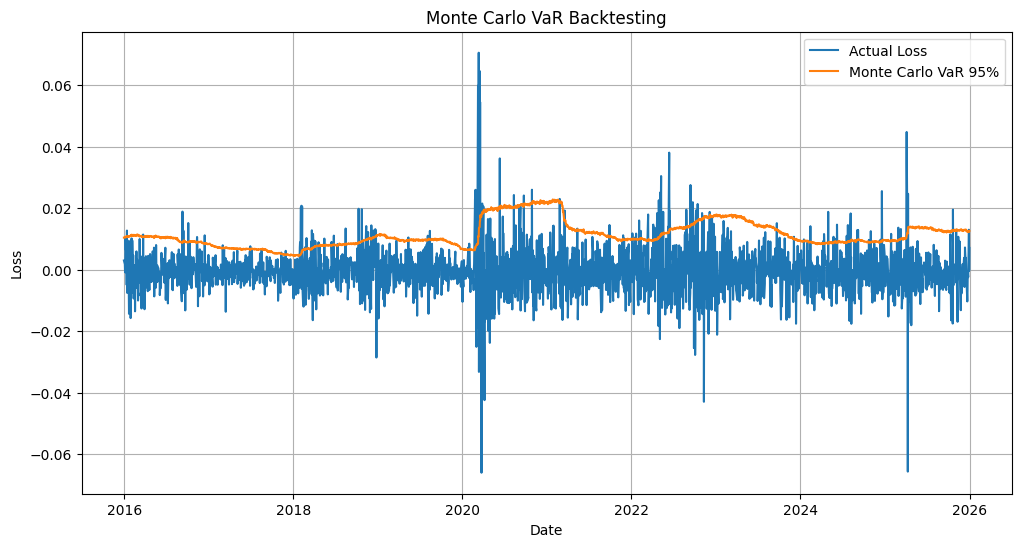

In [12]:
# visualizing Monte Carlo VaR

plt.figure(figsize=(12, 6))

plt.plot(
    backtest.index,
    -backtest["Actual Return"],
    label="Actual Loss"
)

plt.plot(
    backtest.index,
    backtest["Monte Carlo VaR 95%"],
    label="Monte Carlo VaR 95%"
)

plt.title("Monte Carlo VaR Backtesting")
plt.xlabel("Date")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
# Kupiec Proportion of Failures test

def kupiec_test(breaches, confidence):

    n = len(breaches)
    x = breaches.sum()

    p = 1 - confidence

    # observed exception rate
    p_hat = x / n

    # handle zero exceptions
    if x == 0:
        likelihood_ratio = (
            -2 * (
                n * np.log(1 - p)
                - n * np.log(1 - p_hat)
            )
        )

    else:
        likelihood_ratio = -2 * (
            (n - x) * np.log(1 - p)
            + x * np.log(p)
            - (n - x) * np.log(1 - p_hat)
            - x * np.log(p_hat)
        )

    p_value = 1 - chi2.cdf(
        likelihood_ratio,
        df=1
    )

    return likelihood_ratio, p_value

In [14]:
# running Kupiec tests

kupiec_results = []

for model in ["Historical", "Parametric", "Monte Carlo"]:

    for confidence in [95, 99]:

        column = f"{model} Breach {confidence}%"

        confidence_decimal = confidence / 100

        lr_stat, p_value = kupiec_test(
            backtest[column],
            confidence_decimal
        )

        kupiec_results.append({
            "Model": model,
            "Confidence": f"{confidence}%",
            "LR Statistic": lr_stat,
            "p-value": p_value
        })

kupiec_df = pd.DataFrame(kupiec_results)

kupiec_df

,Model,Confidence,LR Statistic,p-value
0,Historical,95%,1.876416,0.170742
1,Historical,99%,4.170945,0.041123
2,Parametric,95%,0.087704,0.767116
3,Parametric,99%,17.891505,0.000023
4,Monte Carlo,95%,0.321978,0.570422
5,Monte Carlo,99%,20.680021,0.000005
